# iTEBD algorithm for H= Σ_i σ_x^i σ_x^(i+1) + h_z * σ_z^i 


In [1]:
import numpy as np
from numpy import linalg as la
from scipy.linalg import *
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# Construct the pauli matrices
sigma_x = np.array([[0,1],[1,0]])
sigma_z = np.array([[1,0],[0,-1]])
I = np.array([[1,0],[0,1]])
dt=0.1
X2 = np.kron(sigma_x,sigma_x)
#print(X2)
J=1.0
Ud = expm(-1j *J * X2 * dt)  # two site operation
h=4
Us = expm(-1j * h * sigma_z * dt) # single site operation
#print(U2)



In [3]:
# State initialization: Given all the spins are +z polarised |000000...>, product state

d = 2  # physical dim
χ1 = 1 # right leg dim of Ta
χ2 = 1 # left leg dim of Ta

λ_a = np.array([[1.0]])
λ_b = np.array([[1.0]])

# All spins |↑> product state
T_a = np.array([1.0, 0.0]).reshape(χ2,d,χ1)   # (χ2,da,χ1) 
T_b = np.array([1.0, 0.0]).reshape(χ1,d,χ2)   # (χ1,db,χ2)



In [4]:
nsteps = 50
M= np.zeros(nsteps) # storing magnetization for site a
N= np.arange(0,nsteps,1)
# initial magnetization calculation
T_a_new = T_a.reshape(d,χ1 * χ2)
Ta_z_app = sigma_z @ T_a_new
M[0] = ((np.conj(T_a_new.reshape(1,d*χ1*χ2)) @ Ta_z_app.reshape(d*χ1*χ2,1)).real)[0][0]
print(M[0])

1.0


In [5]:
with tqdm(total=nsteps) as pbar:
    for k in range(1,nsteps):
        #print(k)
        # Check a single trotter step
        # 2 site operation ---------------------------------------
        # Bond A-B (Ta lambda_a T_b)
        # step 1 : constructing theta from  Ta La Tb
   
        T_a = T_a.reshape(χ2,d*χ1)
        #print(T_a)
        Tm1 = λ_b @ T_a   # (c2,d*c1)
        Tm1 = Tm1.reshape(χ2,d,χ1)
        Tm1 = Tm1.reshape(χ2*d,χ1)
    
        T_b =T_b.reshape(χ1*d,χ2)
        #print(T_b)
        Tm2 =T_b @ λ_b  #(c1*d,c2)
        Tm2 = Tm2.reshape(χ1,d,χ2)
        Tm2 = Tm2.reshape(χ1,d*χ2)
    
        #print(T_a.shape)
        #print(T_b.shape)
        #print(λ_a.shape)

        theta = Tm1 @ λ_a @ Tm2  #(c2*d,d*c2)
   
        #print(la.norm(theta))
    
        # step 2 : Operate the U2 between A-B bond

        theta = theta.reshape(χ2, d, d, χ2).transpose(1, 2, 3, 0).reshape(d*d, χ2*χ2) #--

        theta = Ud @ theta
   
        theta = theta.reshape(d, d, χ2, χ2).transpose(3, 0, 1, 2).reshape(χ2*d, d*χ2)
    
       
        theta= (1/la.norm(theta))*theta    # this step is important other wise svd becomes Nan or inf
        #print(la.norm(theta))

        U1,S1,Vdag1 = la.svd(theta,full_matrices = False)
        #print(max(S1))
        #print((np.conj(U1.T)@U1)[0][0],(np.conj(Vdag1.T)@Vdag1)[0][0])
   
        # step 3 : update T_a = U , T_b = Vdag by necessary truncation of S and update lambda_a to a matrix of (chi1,chi1)
        #-------------------------------------
        # selecting new bond dimension
        val = 1E-12
        χ_max = 50
        #-------------------------------------
    
        count1=0
        for i in range(len(S1)):
            if S1[i] > val:
                count1 = count1 + 1

        if count1 == 0:
            χ1= 1
        elif count1 > χ_max:
            χ1 =  χ_max
        else:
            χ1 = count1
        
        #print(S1[:χ1])
    
        A = (U1[:(χ2*d),:χ1]).reshape(χ2,d,χ1)      # T_a(chi2,d,chi1*),T_b(chi1*,d,chi2)
        B = (Vdag1[:χ1,:(d*χ2)]).reshape(χ1,d,χ2)
        T_a = la.inv(λ_b) @ A.reshape(χ2,d*χ1)    
        T_a = T_a.reshape(χ2,d,χ1)
   
        T_b = B.reshape(χ1*d,χ2)  @ la.inv(λ_b)     
        T_b = T_b.reshape(χ1,d,χ2)
    
        λ_a = np.diag(S1[:χ1])
        #print(np.conj(T_a).T @ T_a)
        #print(np.conj(T_b).T @ T_b)
           
    
        # normalize lambda a
        #λ_a = (1/np.trace((np.conj(λ_a)).T @ λ_a)) * λ_a

        #print(T_a.shape)


        #print(T_az.shape)

        #print(λ_a.shape)
        #-------------------------------------------------------------------
        # Bond B-A : we need to use these updated T_a and T_b , lambda_b 

        # step 4: reshape the new the Ta,Tb

       
        T_a = T_a.reshape(χ2*d,χ1)
        T_b = T_b.reshape(χ1,d*χ2)
        Tn1 = λ_a @ T_b  #(c1,d*c2)
        Tn1 = Tn1.reshape(χ1,d,χ2)
        
        Tn2 = T_a @ λ_a  #(c2*d,c1)
        Tn2 = Tn2.reshape(χ2,d,χ1)

        Tn1= Tn1.reshape(χ1*d,χ2)
        Tn2= Tn2.reshape(χ2,d*χ1)
    
        #print(T_b.shape)

        theta2 = Tn1 @ λ_b @ Tn2  #(chi1*d,d*chi1)
    
        theta2 = theta2.reshape(χ1,d,d,χ1)
        #print(theta2.shape)

        # step 5: apply U 

        theta2 = (theta2.transpose(1,2,3,0)).reshape(d*d,χ1*χ1)
        
        theta2 = Ud @ theta2
  
        theta2 = theta2.reshape(d,d,χ1,χ1).transpose(3,0,1,2).reshape(χ1*d,d*χ1)  
    

        #print(theta2.shape)

        # step 6 :  svd
    
        theta2= (1/la.norm(theta2))*theta2  # normalise
        #print(la.norm(theta2))
        U2,S2,Vdag2 = la.svd(theta2,full_matrices = False)

        # step 7 : update T_a,T_b again, this time λ_b gets updated by selecting the bond dimension of chi2

        # selecting new bond dimension

        count2=0
        for i in range(len(S2)):
            if S2[i] > val:
                count2 = count2 + 1
            
        if count2 == 0:
            χ2= 1
        elif count2 > χ_max:
            χ2 =  χ_max
        else:
            χ2 = count2

        C = (U2[:(χ1*d),:χ2]).reshape(χ1,d,χ2)  
        D = (Vdag2[:χ2,:(d*χ1)]).reshape(χ2,d,χ1)

        T_b =  la.inv(λ_a) @ C.reshape(χ1,d*χ2)   # (c1,d*c2) 
        T_b = T_b.reshape(χ1,d,χ2) # (c1,d,c2)
        T_a = D.reshape(χ2*d,χ1) @ la.inv(λ_a)   # (d*c2,c1)   
        T_a = T_a.reshape(χ2,d,χ1)   #(c2,d,c1)

        λ_b = np.diag(S2[:χ2])           
        # normalize  λ_b
        #λ_b = (1/np.trace((np.conj(λ_b)).T @ λ_b)) * λ_b

        # Now single site operation ----------------------------- only reshape the twice updated Ta Tb and then operating U1
        T_a = Us @ (T_a.transpose(1,2,0)).reshape(d,χ1 * χ2)  #d,c1*c2
        T_b = Us @ (T_b.transpose(1,2,0)).reshape(d,χ2 * χ1)  # d,c2*c1

        T_a= (T_a.reshape(d,χ1,χ2)).transpose(2,0,1)  # (c2,d,c1)
        T_b= (T_b.reshape(d,χ2,χ1)).transpose(2,0,1)  # (c1,d,c2)
    
        #---------------------------------------------------
        # calculating magnetization at A  sites
        # at site A
        Ta_La =  T_a.reshape(χ2*d,χ1) @  λ_a   # (c2*d,c1)
        Ta_La =  Ta_La.reshape(χ2,d,χ1)
        Lb_Ta_La = λ_b @ Ta_La.reshape(χ2,d* χ1)   # (c2,d*c1)
        Lb_Ta_La = Lb_Ta_La.reshape(χ2,d,χ1)   # tensor form after weighted with lambda a & b

        psi = (Lb_Ta_La.transpose(1,2,0)).reshape(d,χ1*χ2)
        Ta_w_z = sigma_z @ psi   # (d,c1*c2)
        psiv = psi.reshape(1,d*χ1*χ2)  # row matrix

        norm = (np.conj(psiv) @ psiv.T)[0][0]
        #print(norm.real)
        if norm <1E-6:
            M[k]=0.0
        else:
            m1= ((np.conj(psiv) @ Ta_w_z.reshape(d*χ1*χ2,1)))/norm
            M[k] = (m1.real)[0][0]
            
        #print(M[k])

        pbar.update(1)
  
        
    

 98%|█████████████████████████████████████████▏| 49/50 [00:00<00:00, 134.39it/s]


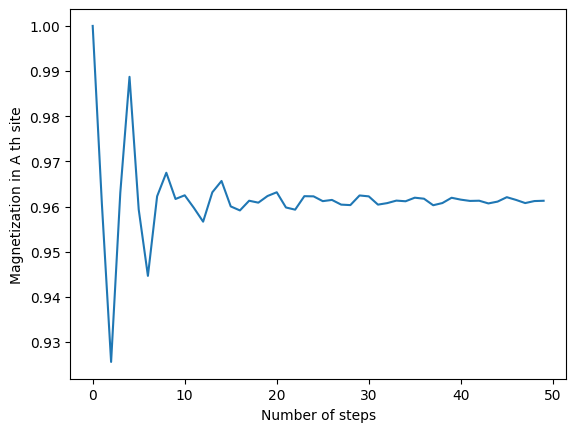

In [6]:

plt.plot(N,M)
plt.xlabel("Number of steps")
plt.ylabel("Magnetization in A th site")
plt.show()
#plt.savefig("iTEBD_h3.png")
